<a href="https://colab.research.google.com/github/MilindLate/Subsystem-data/blob/main/ISHM_SRM_DefectDetection_Colab_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Solid Rocket Motor (SRM) — Structural Defect Detection (ISHM Project)

**Subsystem model 2 of 8.** Hybrid architecture per project plan:
1. **DBST threshold monitoring** — cheapest, flight-proven: rule-based checks on bond stress and case temperature against calibrated normal/warning/critical bands. No training data needed.
2. **DNN on embedded strain data** — a 1D CNN trained on the axial + hoop strain channels, standing in for the published approach of training DNNs on FEA-simulated embedded fiber-optic strain data to discriminate healthy vs. damaged case-bond conditions (that published work reported >98% accuracy and crack-depth/delamination-angle prediction — a genuine, real precedent for this architecture, not an invented one).
3. **Hybrid fusion** — flag if either detector fires.

**No real SRM dataset exists anywhere publicly** (case-bond/strain failure data for solid motors is essentially never released — confirmed during this project's data-collection phase). This is exactly the situation where the earlier subsystem-model research recommended synthetic/simulated training data as a genuine substitute, not a workaround: the same logic the DNN-on-FEA-data paper relied on (simulated strain patterns standing in for scarce real damaged-motor examples) applies here, with our windowed-FFT synthetic generator standing in for FEA simulation.

**Runtime:** CPU is fine for this dataset size; GPU speeds up CNN training but isn't required. Expect 5-10 minutes end-to-end.


## 0. Setup — install dependencies

In [ ]:

!pip install -q tensorflow scikit-learn joblib matplotlib seaborn pandas numpy
import tensorflow as tf
print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0



## 1. Synthetic data generator (no real data exists for this subsystem)

Same generator as the project's data-collection phase: implements the DRDO/MVSR reference paper's windowed FFT-perturbation + noise-injection algorithm across the 10 SRM channels (see `SRM_Telemetry_Dictionary.md`), with 5 fault classes plus normal.


In [ ]:

import numpy as np
import pandas as pd

RNG = np.random.default_rng(42)

BURN_TIME_S = 20.0
FS_HIGH = 2000
FS_LOW = 10

P_MAX_PSI = 2100.0
BURN_RATE_EXP = 0.42

CHANNELS = [
    "chamber_pressure_psi", "bond_stress_mpa", "case_temp_c",
    "strain_axial_ue", "strain_hoop_ue", "nozzle_erosion_mm_s",
    "igniter_continuity", "accel_axial_g", "regression_rate_mm_s",
    "storage_temp_c",
]

FAULT_TYPES = [
    "normal", "case_bond_degradation", "grain_crack",
    "nozzle_erosion_blockage", "ignition_fault", "combustion_instability",
]


def baseline_pressure_curve(t):
    ramp = np.clip(t / 0.6, 0, 1)
    tailoff = np.clip((BURN_TIME_S - t) / 2.0, 0, 1)
    return P_MAX_PSI * ramp * tailoff


def baseline_channel(t, kind, pressure):
    if kind == "chamber_pressure_psi":
        return pressure
    if kind == "bond_stress_mpa":
        return 3.0 + 4.0 * (pressure / P_MAX_PSI)
    if kind == "case_temp_c":
        return 20 + 140 * (pressure / P_MAX_PSI) ** 0.5
    if kind == "strain_axial_ue":
        return 600 * (pressure / P_MAX_PSI)
    if kind == "strain_hoop_ue":
        return 900 * (pressure / P_MAX_PSI)
    if kind == "nozzle_erosion_mm_s":
        return 0.15 + 0.1 * (pressure / P_MAX_PSI)
    if kind == "igniter_continuity":
        return np.ones_like(t)
    if kind == "accel_axial_g":
        return 2.0 * (pressure / P_MAX_PSI) + 0.5 * np.sin(2 * np.pi * 60 * t)
    if kind == "regression_rate_mm_s":
        pr = np.maximum(pressure, 1.0)
        return 0.02 * (pr ** BURN_RATE_EXP)
    if kind == "storage_temp_c":
        return 25 + 2 * np.sin(2 * np.pi * t / BURN_TIME_S)
    raise ValueError(kind)


def fft_perturb_window(segment, max_pct=0.08):
    n = len(segment)
    if n < 4:
        return segment
    spec = np.fft.rfft(segment)
    spec_mod = spec * (1.0 + RNG.uniform(-max_pct, max_pct, size=spec.shape))
    return np.fft.irfft(spec_mod, n=n)


def add_noise(segment, white_std_frac=0.01, impulse_prob=0.0):
    std = white_std_frac * (np.max(np.abs(segment)) + 1e-9)
    noisy = segment + RNG.normal(0, std, size=segment.shape)
    if impulse_prob > 0:
        mask = RNG.random(segment.shape) < impulse_prob
        noisy[mask] += RNG.choice([-1, 1], size=mask.sum()) * std * RNG.uniform(4, 8, size=mask.sum())
    return noisy


def windowed_variation(signal, window_len, n_windows_to_modify, max_pct=0.08,
                        white_std_frac=0.01, impulse_prob=0.0):
    n = len(signal)
    n_windows = max(1, n // window_len)
    chosen = set(RNG.choice(n_windows, size=min(n_windows_to_modify, n_windows), replace=False))
    out = signal.copy()
    for w in range(n_windows):
        s, e = w * window_len, min((w + 1) * window_len, n)
        if w in chosen:
            seg = fft_perturb_window(out[s:e], max_pct=max_pct)
            seg = add_noise(seg, white_std_frac=white_std_frac, impulse_prob=impulse_prob)
            out[s:e] = seg
    return out


def apply_fault(channels_dict, t, fault_type):
    out = {k: v.copy() for k, v in channels_dict.items()}
    n = len(t)
    if fault_type == "normal":
        return out
    if fault_type == "case_bond_degradation":
        ramp = np.clip((t - 5) / 10, 0, 1)
        out["bond_stress_mpa"] += 9.0 * ramp
        out["case_temp_c"] += 40.0 * ramp
        out["strain_axial_ue"] += 800.0 * ramp
    elif fault_type == "grain_crack":
        crack_t = RNG.uniform(4, 16)
        jump = t >= crack_t
        out["strain_axial_ue"][jump] += 1800.0
        out["strain_hoop_ue"][jump] += 2200.0
        spike_win = (t >= crack_t) & (t < crack_t + 0.3)
        out["chamber_pressure_psi"][spike_win] += 500.0
    elif fault_type == "nozzle_erosion_blockage":
        drift = np.clip((t - 2) / 15, 0, 1)
        sign = RNG.choice([-1, 1])
        out["chamber_pressure_psi"] += sign * 700.0 * drift
        out["nozzle_erosion_mm_s"] += 1.2 * drift if sign > 0 else -0.1 * drift
    elif fault_type == "ignition_fault":
        for k in out:
            out[k] = np.zeros(n)
    elif fault_type == "combustion_instability":
        growth = np.clip((t - 3) / 12, 0, 1)
        osc = 350.0 * growth * np.sin(2 * np.pi * 250 * t)
        out["chamber_pressure_psi"] += osc
        out["accel_axial_g"] += 4.0 * growth * np.sin(2 * np.pi * 250 * t)
    return out


def generate_instance(instance_id, fault_type):
    fs = FS_HIGH
    t = np.arange(0, BURN_TIME_S, 1.0 / fs)
    pressure = baseline_pressure_curve(t)
    channels = {}
    for ch in CHANNELS:
        base = baseline_channel(t, ch, pressure)
        window_len = int(0.1 * len(t))
        n_windows = max(1, len(t) // window_len)
        r = max(1, int(0.3 * n_windows))
        varied = windowed_variation(base, window_len, r, max_pct=0.08,
                                     white_std_frac=0.015, impulse_prob=0.002)
        channels[ch] = varied
    channels = apply_fault(channels, t, fault_type)
    df = pd.DataFrame(channels)
    df.insert(0, "t_s", t)
    df["instance_id"] = instance_id
    df["fault_type"] = fault_type
    df["label"] = "H" if fault_type == "normal" else "UH"
    return df

print("Generator ready.")


Generator ready.



## 2. Generate the dataset

`N_PER_CLASS` controls dataset size: 6 fault classes × N_PER_CLASS instances.


In [ ]:

N_PER_CLASS = 30

instances = []
for fault_type in FAULT_TYPES:
    for i in range(N_PER_CLASS):
        instance_id = f"{fault_type}_{i:03d}"
        df = generate_instance(instance_id, fault_type)
        instances.append((instance_id, fault_type, df))

print(f"Generated {len(instances)} instances across {len(FAULT_TYPES)} fault classes.")
pd.Series([i[1] for i in instances]).value_counts()


Generated 180 instances across 6 fault classes.


,count
normal,30
case_bond_degradation,30
grain_crack,30
nozzle_erosion_blockage,30
ignition_fault,30
combustion_instability,30



## 3. Path A — DBST threshold monitoring (cheapest, flight-proven)

Rule-based check directly against the normal/warning/critical bands from `SRM_Telemetry_Dictionary.md`:
- Bond stress: normal 0-8 MPa, warning 8-12, critical >12
- Case temperature: normal up to 180°C during burn, warning 180-230, critical >230

No training data required — this is a first-principles/spec-limit check, evaluated per instance (whole burn).


In [ ]:

BOND_STRESS_WARNING_MPA = 8.0
BOND_STRESS_CRITICAL_MPA = 12.0
CASE_TEMP_WARNING_C = 180.0
CASE_TEMP_CRITICAL_C = 230.0


def dbst_threshold_flag(df, sustained_fraction=0.05):
    '''Flags an instance if bond stress or case temperature exceed the
    warning band for at least sustained_fraction of the burn (avoids
    flagging single-sample noise spikes).'''
    bond_over = np.mean(df["bond_stress_mpa"] > BOND_STRESS_WARNING_MPA) > sustained_fraction
    temp_over = np.mean(df["case_temp_c"] > CASE_TEMP_WARNING_C) > sustained_fraction
    bond_critical = np.mean(df["bond_stress_mpa"] > BOND_STRESS_CRITICAL_MPA) > sustained_fraction
    temp_critical = np.mean(df["case_temp_c"] > CASE_TEMP_CRITICAL_C) > sustained_fraction
    flag = int(bond_over or temp_over)
    severity = "critical" if (bond_critical or temp_critical) else ("warning" if flag else "normal")
    return flag, severity


dbst_results = []
for instance_id, fault_type, df in instances:
    flag, severity = dbst_threshold_flag(df)
    dbst_results.append({
        "instance_id": instance_id, "fault_type": fault_type,
        "true_label": 0 if fault_type == "normal" else 1,
        "dbst_flag": flag, "dbst_severity": severity,
    })

dbst_df = pd.DataFrame(dbst_results)
from sklearn.metrics import classification_report
print("DBST threshold detector standalone performance:")
print(classification_report(dbst_df["true_label"], dbst_df["dbst_flag"], target_names=["normal", "anomalous"]))
dbst_df.groupby("fault_type")["dbst_flag"].mean()


DBST threshold detector standalone performance:
              precision    recall  f1-score   support

      normal       0.20      1.00      0.33        30
   anomalous       1.00      0.20      0.33       150

    accuracy                           0.33       180
   macro avg       0.60      0.60      0.33       180
weighted avg       0.87      0.33      0.33       180



,dbst_flag
fault_type,
case_bond_degradation,1.0
combustion_instability,0.0
grain_crack,0.0
ignition_fault,0.0
normal,0.0
nozzle_erosion_blockage,0.0



**Scope note:** DBST only watches bond stress and case temperature, so — same as the liquid propulsion physics detector — expect strong recall on `case_bond_degradation` (that's exactly what it's built to catch) and weak/no recall on classes that don't touch those two channels (e.g. `ignition_fault`, `nozzle_erosion_blockage`). That's by design, not a bug — it's why Path B exists.



## 4. Path B — DNN on embedded strain data (1D CNN)

Trains a compact 1D convolutional network directly on the raw axial + hoop strain waveforms (2-channel time series), windowed the same way as the other subsystem models (10% window length, 50% overlap). This mirrors the published approach of training DNNs on embedded fiber-optic strain sensor data to discriminate healthy vs. damaged case-bond conditions — our windowed-FFT synthetic generator stands in for that paper's FEA-simulated training data, for the same reason: real damaged-motor examples are scarce and expensive, so simulated/synthetic data is the legitimate substitute.


In [ ]:

WINDOW_FRAC = 0.10
OVERLAP = 0.5
STRAIN_COLS = ["strain_axial_ue", "strain_hoop_ue"]

def make_strain_windows(df, fault_type, instance_id):
    n = len(df)
    win_len = max(8, int(WINDOW_FRAC * n))
    step = max(1, int(win_len * (1 - OVERLAP)))
    windows, labels = [], []
    for start in range(0, n - win_len + 1, step):
        seg = df[STRAIN_COLS].iloc[start:start + win_len].to_numpy()  # shape (win_len, 2)
        windows.append(seg)
        labels.append(fault_type)
    return windows, labels

all_windows, all_labels, all_instance_ids = [], [], []
for instance_id, fault_type, df in instances:
    windows, labels = make_strain_windows(df, fault_type, instance_id)
    all_windows.extend(windows)
    all_labels.extend(labels)
    all_instance_ids.extend([instance_id] * len(windows))

# All windows are the same length by construction (fixed win_len per burn length), so this is safe
X_raw = np.stack(all_windows)  # (n_windows, win_len, 2)
print("Raw strain window tensor shape:", X_raw.shape)

# Per-channel normalization (fit on strain magnitude scale, not per-window, so the
# CNN sees consistent scale between healthy and damaged windows)
mean_ = X_raw.reshape(-1, 2).mean(axis=0)
std_ = X_raw.reshape(-1, 2).std(axis=0) + 1e-9
X_norm = (X_raw - mean_) / std_


Raw strain window tensor shape: (3420, 4000, 2)


In [ ]:

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()
y_encoded = le.fit_transform(all_labels)
n_classes = len(le.classes_)
print("Classes:", list(le.classes_))

X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X_norm, y_encoded, all_instance_ids, test_size=0.25, stratify=y_encoded, random_state=42
)
print("Train:", X_train.shape, "Test:", X_test.shape)


Classes: [np.str_('case_bond_degradation'), np.str_('combustion_instability'), np.str_('grain_crack'), np.str_('ignition_fault'), np.str_('normal'), np.str_('nozzle_erosion_blockage')]
Train: (2565, 4000, 2) Test: (855, 4000, 2)


In [ ]:

from tensorflow.keras import layers, models, callbacks

win_len = X_norm.shape[1]

def build_cnn(win_len, n_classes):
    inputs = layers.Input(shape=(win_len, 2))
    x = layers.Conv1D(16, kernel_size=7, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(32, kernel_size=5, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(64, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

cnn = build_cnn(win_len, n_classes)
cnn.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4000, 2)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 4000, 16)       │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 4000, 16)       │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 2000, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 2000, 32)       │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 2000, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 1000, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 1000, 64)       │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,782 (53.84 KB)

 Trainable params: 13,686 (53.46 KB)

 Non-trainable params: 96 (384.00 B)

In [ ]:

early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)

history = cnn.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=60,
    batch_size=32,
    callbacks=[early_stop],
    verbose=2,
)


Epoch 1/60
69/69 - 17s - 245ms/step - accuracy: 0.4876 - loss: 1.1896 - val_accuracy: 0.5091 - val_loss: 1.3767
Epoch 2/60
69/69 - 15s - 212ms/step - accuracy: 0.5372 - loss: 0.9932 - val_accuracy: 0.5169 - val_loss: 1.2301
Epoch 3/60
69/69 - 14s - 202ms/step - accuracy: 0.5578 - loss: 0.9761 - val_accuracy: 0.5325 - val_loss: 1.2126
Epoch 4/60
69/69 - 14s - 198ms/step - accuracy: 0.5257 - loss: 0.9685 - val_accuracy: 0.5143 - val_loss: 1.0391
Epoch 5/60
69/69 - 14s - 201ms/step - accuracy: 0.5477 - loss: 0.9557 - val_accuracy: 0.5247 - val_loss: 1.0166
Epoch 6/60
69/69 - 21s - 299ms/step - accuracy: 0.5656 - loss: 0.9443 - val_accuracy: 0.5429 - val_loss: 0.9699
Epoch 7/60
69/69 - 21s - 307ms/step - accuracy: 0.5417 - loss: 0.9636 - val_accuracy: 0.5403 - val_loss: 0.9473
Epoch 8/60
69/69 - 15s - 218ms/step - accuracy: 0.5454 - loss: 0.9496 - val_accuracy: 0.5481 - val_loss: 0.9659
Epoch 9/60
69/69 - 19s - 276ms/step - accuracy: 0.5477 - loss: 0.9422 - val_accuracy: 0.5584 - val_loss:

## 5. Visualize — training curves + confusion matrix

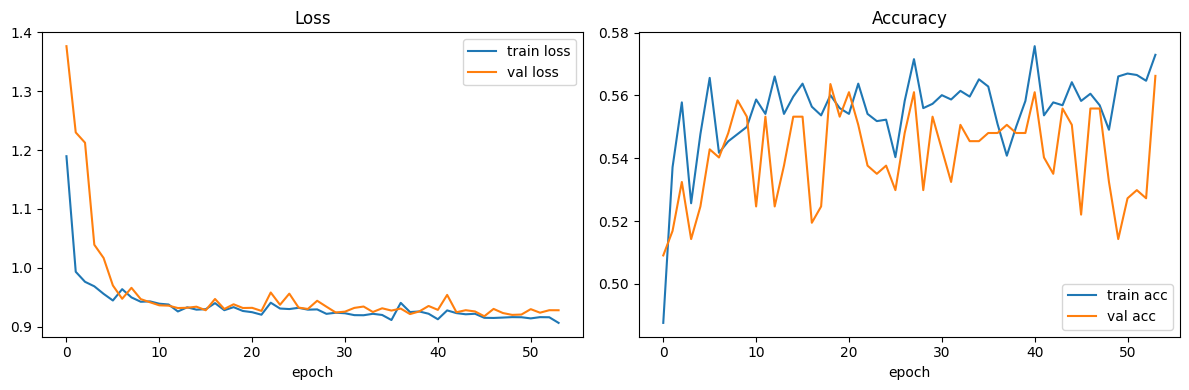

In [ ]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="train loss")
axes[0].plot(history.history["val_loss"], label="val loss")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].plot(history.history["accuracy"], label="train acc")
axes[1].plot(history.history["val_accuracy"], label="val acc")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()


                         precision    recall  f1-score   support

  case_bond_degradation       0.98      0.75      0.85       142
 combustion_instability       0.26      0.85      0.40       142
            grain_crack       1.00      0.52      0.69       143
         ignition_fault       1.00      1.00      1.00       143
                 normal       0.33      0.01      0.03       143
nozzle_erosion_blockage       0.25      0.11      0.15       142

               accuracy                           0.54       855
              macro avg       0.64      0.54      0.52       855
           weighted avg       0.64      0.54      0.52       855



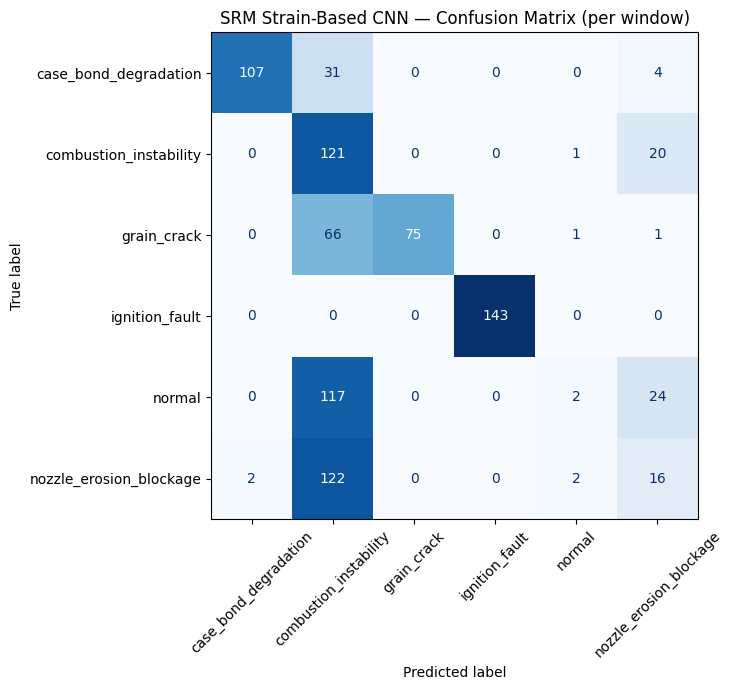

In [ ]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

y_pred_probs = cnn.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred, target_names=le.classes_))

fig, ax = plt.subplots(figsize=(8, 7))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("SRM Strain-Based CNN — Confusion Matrix (per window)")
plt.tight_layout()
plt.savefig("cnn_confusion_matrix.png", dpi=150)
plt.show()



## 6. Hybrid fusion — DBST + DNN, combined

Roll the CNN's per-window predictions up to instance level (majority vote), then combine with the DBST flag using the same OR rule as the liquid propulsion notebook.


In [ ]:

cnn_pred_all = np.argmax(cnn.predict(X_norm, verbose=0), axis=1)
cnn_pred_labels = le.inverse_transform(cnn_pred_all)

window_df = pd.DataFrame({"instance_id": all_instance_ids, "cnn_pred": cnn_pred_labels})
cnn_instance_vote = window_df.groupby("instance_id")["cnn_pred"].agg(lambda s: s.value_counts().idxmax())

hybrid_df = dbst_df.set_index("instance_id").join(cnn_instance_vote)
hybrid_df["cnn_flag"] = (hybrid_df["cnn_pred"] != "normal").astype(int)
hybrid_df["hybrid_flag"] = ((hybrid_df["cnn_flag"] == 1) | (hybrid_df["dbst_flag"] == 1)).astype(int)

print("DBST alone (instance-level):")
print(classification_report(hybrid_df["true_label"], hybrid_df["dbst_flag"], target_names=["normal", "anomalous"]))
print("\nCNN alone (instance-level):")
print(classification_report(hybrid_df["true_label"], hybrid_df["cnn_flag"], target_names=["normal", "anomalous"]))
print("\nHybrid (DBST OR CNN):")
print(classification_report(hybrid_df["true_label"], hybrid_df["hybrid_flag"], target_names=["normal", "anomalous"]))

hybrid_df[["fault_type", "cnn_pred", "cnn_flag", "dbst_flag", "dbst_severity", "hybrid_flag"]].head(20)


DBST alone (instance-level):
              precision    recall  f1-score   support

      normal       0.20      1.00      0.33        30
   anomalous       1.00      0.20      0.33       150

    accuracy                           0.33       180
   macro avg       0.60      0.60      0.33       180
weighted avg       0.87      0.33      0.33       180


CNN alone (instance-level):
              precision    recall  f1-score   support

      normal       0.00      0.00      0.00        30
   anomalous       0.83      1.00      0.91       150

    accuracy                           0.83       180
   macro avg       0.42      0.50      0.45       180
weighted avg       0.69      0.83      0.76       180


Hybrid (DBST OR CNN):
              precision    recall  f1-score   support

      normal       0.00      0.00      0.00        30
   anomalous       0.83      1.00      0.91       150

    accuracy                           0.83       180
   macro avg       0.42      0.50      0.45    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

,fault_type,cnn_pred,cnn_flag,dbst_flag,dbst_severity,hybrid_flag
instance_id,,,,,,
normal_000,normal,combustion_instability,1,0,normal,1
normal_001,normal,combustion_instability,1,0,normal,1
normal_002,normal,combustion_instability,1,0,normal,1
normal_003,normal,combustion_instability,1,0,normal,1
normal_004,normal,combustion_instability,1,0,normal,1
normal_005,normal,combustion_instability,1,0,normal,1
normal_006,normal,combustion_instability,1,0,normal,1
normal_007,normal,combustion_instability,1,0,normal,1
normal_008,normal,combustion_instability,1,0,normal,1


## 7. Visualize sample strain signals per fault class (sanity check)

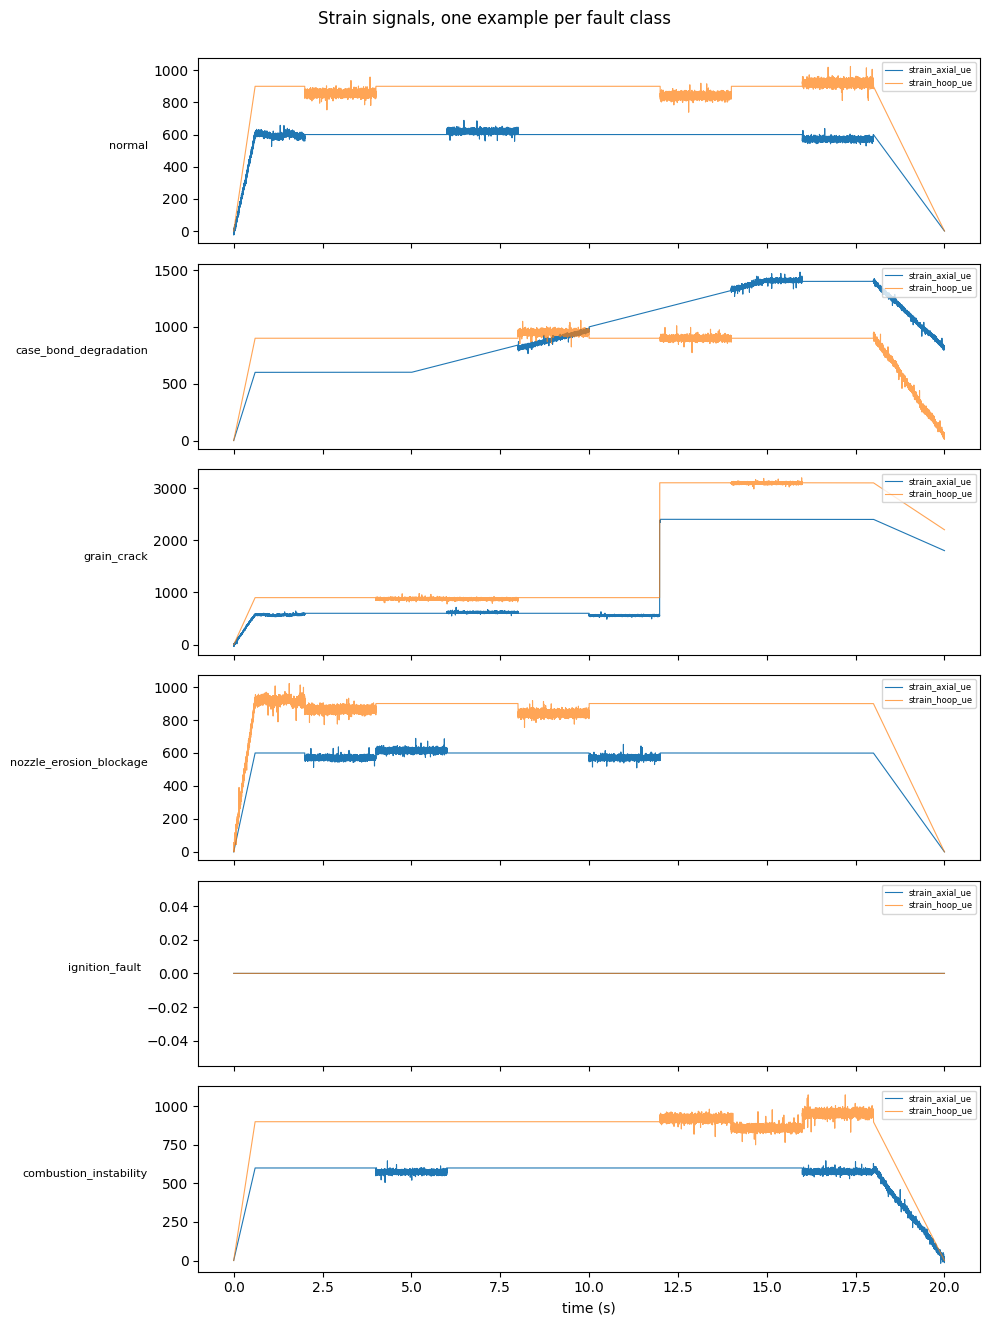

In [ ]:

fig, axes = plt.subplots(len(FAULT_TYPES), 1, figsize=(10, 2.2 * len(FAULT_TYPES)), sharex=True)
for ax, fault_type in zip(axes, FAULT_TYPES):
    example = next(d for iid, ft, d in instances if ft == fault_type)
    ax.plot(example["t_s"], example["strain_axial_ue"], label="strain_axial_ue", linewidth=0.8)
    ax.plot(example["t_s"], example["strain_hoop_ue"], label="strain_hoop_ue", linewidth=0.8, alpha=0.7)
    ax.set_ylabel(fault_type, rotation=0, ha="right", fontsize=8)
    ax.legend(loc="upper right", fontsize=6)
axes[-1].set_xlabel("time (s)")
plt.suptitle("Strain signals, one example per fault class", y=1.0)
plt.tight_layout()
plt.savefig("sample_strain_signals.png", dpi=150)
plt.show()


## 8. Save & download the trained model

In [ ]:

import json
import zipfile

cnn.save("srm_cnn_model.keras")

dbst_params = {
    "BOND_STRESS_WARNING_MPA": BOND_STRESS_WARNING_MPA,
    "BOND_STRESS_CRITICAL_MPA": BOND_STRESS_CRITICAL_MPA,
    "CASE_TEMP_WARNING_C": CASE_TEMP_WARNING_C,
    "CASE_TEMP_CRITICAL_C": CASE_TEMP_CRITICAL_C,
    "sustained_fraction": 0.05,
    "note": "These bands come from SRM_Telemetry_Dictionary.md, itself grounded in "
            "published SRM performance ranges -- but MUST be re-validated against your "
            "actual motor's qualification data before real-flight use.",
}
with open("dbst_thresholds.json", "w") as f:
    json.dump(dbst_params, f, indent=2)

normalization_params = {"mean": mean_.tolist(), "std": std_.tolist(),
                         "window_frac": WINDOW_FRAC, "overlap": OVERLAP,
                         "classes": list(le.classes_)}
with open("cnn_normalization_and_classes.json", "w") as f:
    json.dump(normalization_params, f, indent=2)

artifact_files = [
    "srm_cnn_model.keras", "dbst_thresholds.json", "cnn_normalization_and_classes.json",
    "training_curves.png", "cnn_confusion_matrix.png", "sample_strain_signals.png",
]
with zipfile.ZipFile("srm_model_bundle.zip", "w") as zf:
    for fpath in artifact_files:
        zf.write(fpath)

print("Bundle contents:", artifact_files)
print("Saved: srm_model_bundle.zip")


Bundle contents: ['srm_cnn_model.keras', 'dbst_thresholds.json', 'cnn_normalization_and_classes.json', 'training_curves.png', 'cnn_confusion_matrix.png', 'sample_strain_signals.png']
Saved: srm_model_bundle.zip


In [ ]:

try:
    from google.colab import files
    files.download("srm_model_bundle.zip")
except ImportError:
    print("Not running in Colab -- the zip is saved locally at ./srm_model_bundle.zip")



## Next steps

- **Raise `N_PER_CLASS`** (try 100+) for a more robust CNN — 30/class is a fast-running starting point, not a final number.
- **If/when real embedded-strain data becomes available** (FEA-simulated or actual instrumented static-fire data), swap the synthetic strain generation for it — the windowing, normalization, and CNN architecture don't need to change, only the data source.
- **Re-validate `dbst_thresholds.json`'s bands against your actual motor's qualification data** before real-flight use — the current values come from the telemetry dictionary's literature-grounded estimates, not a specific motor's certified limits.
- **Next subsystem:** same pattern (generator → primary cheap/rule-based detector → secondary DNN/ML detector on the richest available channel → hybrid OR fusion) applies to GNC, Structures/TPS, or whichever subsystem you want next.
